# **DenseNet w/o XAI**

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


2025-07-20 14:16:32.176265: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-20 14:16:32.185711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752999392.197094  762048 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752999392.200803  762048 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752999392.211745  762048 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


I0000 00:00:1752999403.084261  762048 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7464 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 119s 4us/step


Model: "functional"

...

 1/51 ━━━━━━━━━━━━━━━━━━━━ 1:02:44 75s/step - accuracy: 0.1429 - loss: 2.0171

I0000 00:00:1752999617.134271  762780 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-07-20 14:20:18.986969: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11958', 212 bytes spill stores, 212 bytes spill loads

2025-07-20 14:20:18.989382: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11958', 76 bytes spill stores, 76 bytes spill loads

2025-07-20 14:20:19.152811: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11958', 3788 bytes spill stores, 3780 bytes spill loads

2025-07-20 14:20:19.219736: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warn

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.2087 - loss: 1.7466

2025-07-20 14:20:53.108967: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 132 bytes spill stores, 132 bytes spill loads

2025-07-20 14:20:53.112805: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 4 bytes spill stores, 4 bytes spill loads

2025-07-20 14:20:53.329559: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 2752 bytes spill stores, 2752 bytes spill loads



51/51 ━━━━━━━━━━━━━━━━━━━━ 116s 809ms/step - accuracy: 0.2089 - loss: 1.7459 - val_accuracy: 0.2217 - val_loss: 1.6333
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.2241 - loss: 1.6656 - val_accuracy: 0.2652 - val_loss: 1.5728
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.2736 - loss: 1.5782 - val_accuracy: 0.3304 - val_loss: 1.5317
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.3115 - loss: 1.5543 - val_accuracy: 0.3391 - val_loss: 1.4897
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.3419 - loss: 1.4961 - val_accuracy: 0.3478 - val_loss: 1.4634
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 270ms/step - accuracy: 0.3447 - loss: 1.4838 - val_accuracy: 0.4217 - val_loss: 1.4239
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.3709 - loss: 1.4186 - val_accuracy: 0.4304 - val_loss: 1.3917
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.3997 - loss: 1.4039 - val_accurac

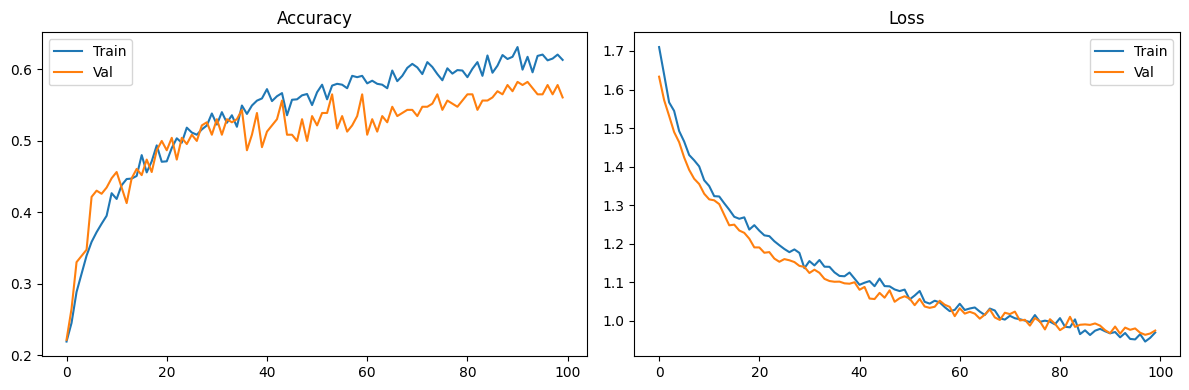

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6800 - loss: 0.7813

2025-07-20 14:39:44.807192: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 4 bytes spill stores, 4 bytes spill loads

2025-07-20 14:39:44.820299: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 224 bytes spill stores, 224 bytes spill loads

2025-07-20 14:39:44.822066: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 132 bytes spill stores, 132 bytes spill loads

2025-07-20 14:39:45.011064: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3316', 3948 bytes spill stores, 3936 bytes spill loads

2025-07-20 14:39:45.017977: I exte

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 606ms/step - accuracy: 0.6653 - loss: 0.8138

Test Accuracy : 0.5622
Test Loss     : 1.0411
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.88      0.63       101
           1       0.47      0.43      0.45        99
           2       0.48      0.43      0.45        94
           3       0.85      0.51      0.63        89
           4       0.80      0.54      0.65        83

    accuracy                           0.56       466
   macro avg       0.62      0.56      0.56       466
weighted avg       0.61      0.56      0.56       466

Precision (weighted): 0.6072
Recall    (weighted): 0.5622
F1 Score  (weighted): 0.5595


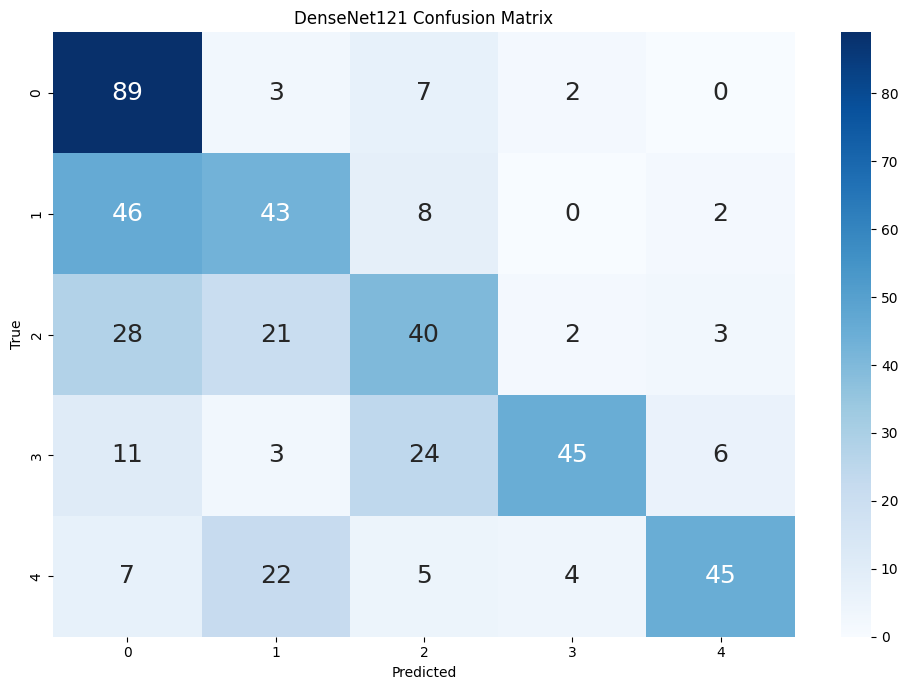

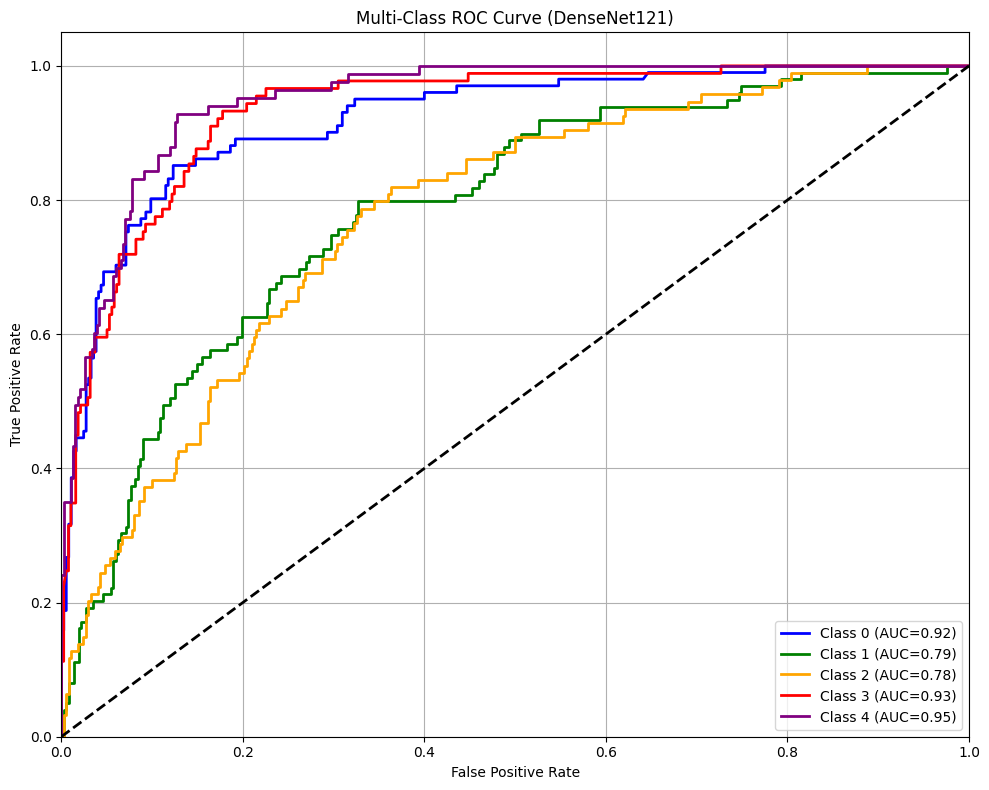

In [ ]:
"""
Baseline DenseNet121 for 5‑class knee‑X‑ray classification.

Directory layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ───────────────────── 1. IMPORTS ─────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score,
    recall_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ───────────────────── 2. PARAMETERS ──────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE   = (224, 224)       # DenseNet121 default
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ────────────── 3. BPHE + PREPROCESS ────────────────
def bphe_rgb(img):
    """BPHE on Y channel, then DenseNet preprocess_input."""
    img = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ───────────── 4. DATA GENERATORS ───────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ───────────── 5. BUILD MODEL ───────────────
base = DenseNet121(weights='imagenet', include_top=False,
                   input_shape=IMG_SIZE + (3,))

x = GlobalAveragePooling2D()(base.output)
out = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=out)

# Freeze feature extractor
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ───────────── 6. TRAINING ───────────────
history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen
)

# ─────── 7. ACCURACY & LOSS PLOTS ────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ───────── 8. EVALUATION ─────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

test_gen.reset()
prob   = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion matrix heat‑map
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':18})
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('DenseNet121 Confusion Matrix')
plt.tight_layout(); plt.show()

# ───────── 9. ROC CURVE ─────────
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
fpr, tpr, roc_auc = {}, {}, {}
plt.figure(figsize=(10,8))
colors = ['blue','green','orange','red','purple']
for i, c in enumerate(colors):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=c, lw=2,
             label=f'Class {i} (AUC={roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--',lw=2)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Multi‑Class ROC Curve (DenseNet121)')
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout(); plt.show()


Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,331,589 (69.93 MB)

 Trainable params: 9,605 (37.52 KB)

...

18/51 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.1770 - loss: 2.5930

2025-07-20 14:40:36.808800: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19798', 172 bytes spill stores, 172 bytes spill loads

2025-07-20 14:40:36.842603: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19798', 172 bytes spill stores, 172 bytes spill loads

2025-07-20 14:40:36.938911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19798', 1680 bytes spill stores, 1640 bytes spill loads



51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.1851 - loss: 2.2947

2025-07-20 14:41:04.430093: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 172 bytes spill stores, 172 bytes spill loads

2025-07-20 14:41:04.444567: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 172 bytes spill stores, 172 bytes spill loads

2025-07-20 14:41:04.658929: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 1564 bytes spill stores, 1564 bytes spill loads



51/51 ━━━━━━━━━━━━━━━━━━━━ 59s 804ms/step - accuracy: 0.1853 - loss: 2.2890 - val_accuracy: 0.2435 - val_loss: 1.6537
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 262ms/step - accuracy: 0.2435 - loss: 1.6854 - val_accuracy: 0.2783 - val_loss: 1.5803
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 207ms/step - accuracy: 0.2747 - loss: 1.6032 - val_accuracy: 0.3435 - val_loss: 1.5267
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 207ms/step - accuracy: 0.2627 - loss: 1.5844 - val_accuracy: 0.3217 - val_loss: 1.4727
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 261ms/step - accuracy: 0.3221 - loss: 1.5223 - val_accuracy: 0.4043 - val_loss: 1.4188
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - accuracy: 0.3673 - loss: 1.4370 - val_accuracy: 0.4522 - val_loss: 1.3909
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.4051 - loss: 1.4094 - val_accuracy: 0.4435 - val_loss: 1.3441
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 264ms/step - accuracy: 0.3847 - loss: 1.4032 - val_accuracy

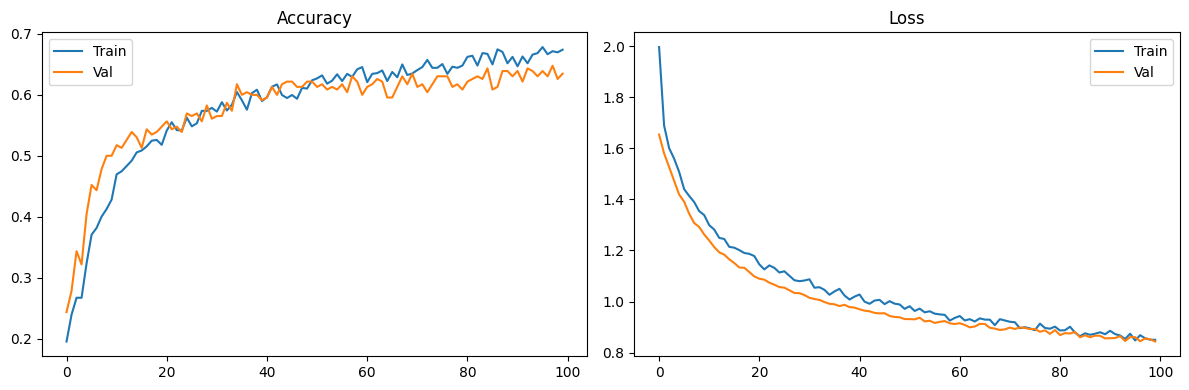

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6723 - loss: 0.7824

2025-07-20 15:00:17.783375: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 172 bytes spill stores, 172 bytes spill loads

2025-07-20 15:00:17.788294: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 172 bytes spill stores, 172 bytes spill loads

2025-07-20 15:00:17.797701: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 384 bytes spill stores, 384 bytes spill loads

2025-07-20 15:00:17.912496: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5436', 1664 bytes spill stores, 1616 bytes spill loads

2025-07-20 15:00:17.987388: I 

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 793ms/step - accuracy: 0.6644 - loss: 0.7960

Test Accuracy : 0.6094
Test Loss     : 0.8913
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 715ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.81      0.71       101
           1       0.47      0.52      0.49        99
           2       0.46      0.46      0.46        94
           3       0.82      0.60      0.69        89
           4       0.77      0.66      0.71        83

    accuracy                           0.61       466
   macro avg       0.63      0.61      0.61       466
weighted avg       0.63      0.61      0.61       466

Precision (weighted): 0.6251
Recall    (weighted): 0.6094
F1 Score  (weighted): 0.6107


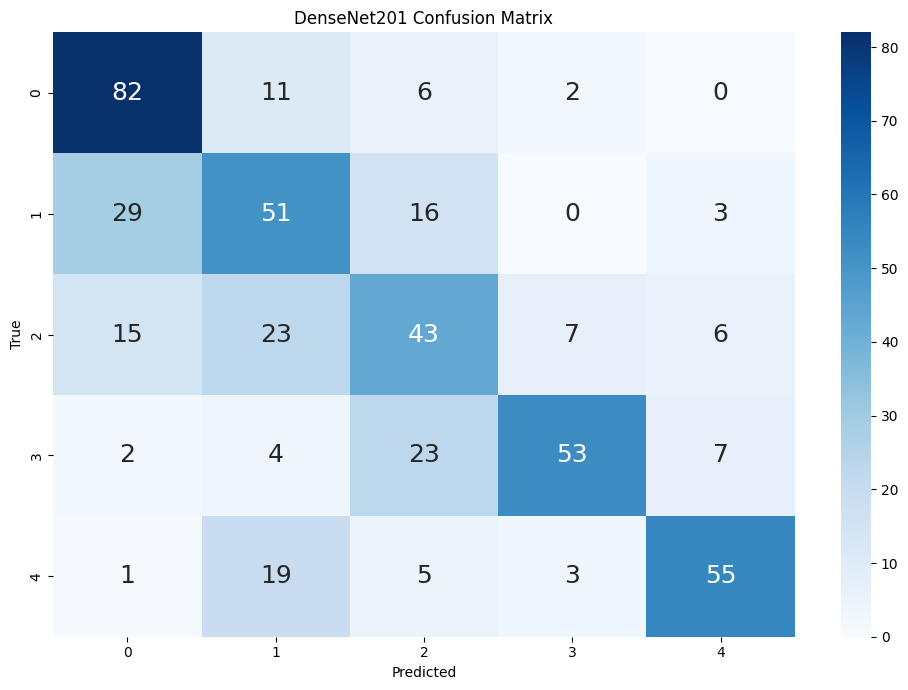

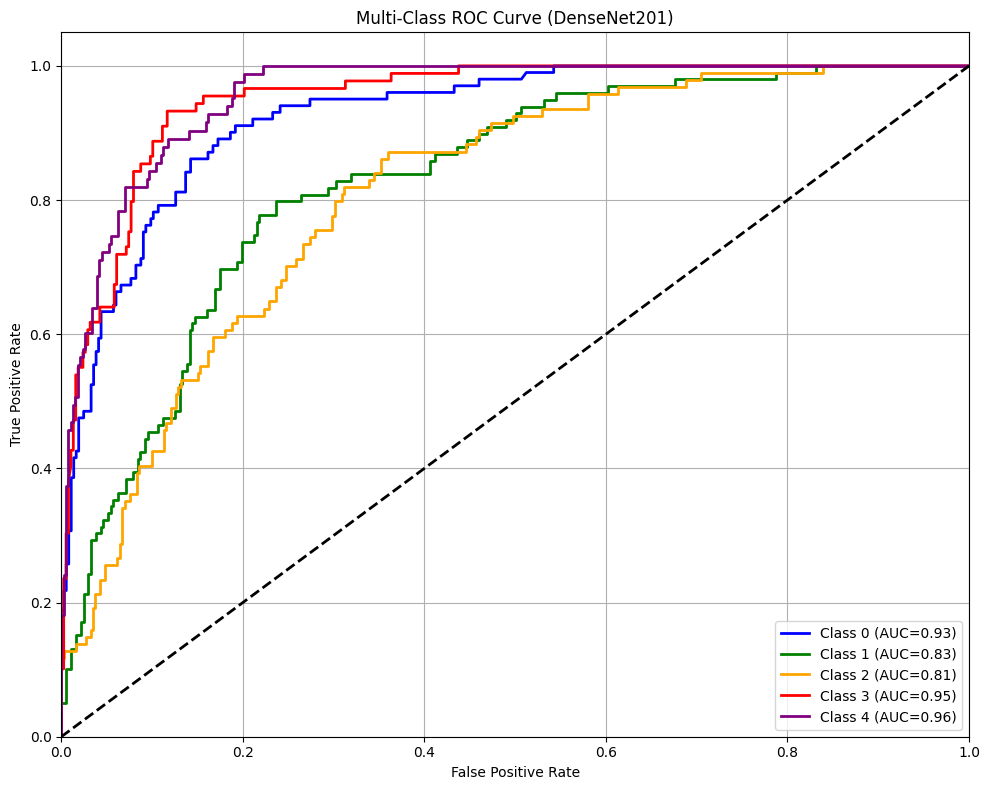

In [ ]:
"""
Baseline DenseNet201 for 5‑class knee‑X‑ray classification.

Directory layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ───────────────────── 1. IMPORTS ─────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score,
    recall_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ───────────────────── 2. PARAMETERS ──────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE   = (224, 224)        # DenseNet201 default resolution
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ────────────── 3. BPHE + PREPROCESS ────────────────
def bphe_rgb(img):
    """BPHE on Y channel, then DenseNet preprocess_input."""
    img = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ───────────── 4. DATA GENERATORS ───────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ───────────── 5. BUILD MODEL ───────────────
base = DenseNet201(weights='imagenet', include_top=False,
                   input_shape=IMG_SIZE + (3,))

x = GlobalAveragePooling2D()(base.output)
out = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=out)

# Freeze feature extractor
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ───────────── 6. TRAINING ───────────────
history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen
)

# ─────── 7. ACCURACY & LOSS PLOTS ────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ───────── 8. EVALUATION ─────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

test_gen.reset()
prob   = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':18})
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('DenseNet201 Confusion Matrix')
plt.tight_layout(); plt.show()

# ───────── 9. ROC CURVE ─────────
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
fpr, tpr, roc_auc = {}, {}, {}
plt.figure(figsize=(10,8))
colors = ['blue','green','orange','red','purple']
for i, c in enumerate(colors):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=c, lw=2,
             label=f'Class {i} (AUC={roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--',lw=2)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Multi‑Class ROC Curve (DenseNet201)')
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout(); plt.show()
